In [1]:
%matplotlib widget

# Piecewise 1D inversion of 3D channel

In [30]:
import numpy as np
import pygimli as pg
import empymod as ep
import sys
import matplotlib.pyplot as plt
sys.path.insert(1, '../src')

from FDEM1D import FDEM1DModelling_nosort

from showStitched import showStitchedModels

from Plot import grid

# Load data

In [31]:
print('Using files:')
print('data/data_3DChannel_nosort_topo.npy')
print()

# model parameters [h_1, sigma_1, sigma_2]

data = np.load('data/data_3DChannel_nosort_topo.npy')

Using files:
data/data_3DChannel_nosort_topo.npy



In [32]:
# Load true model

model_true_full = np.load('models/model_3DChannel_topo.npy')

model_true = np.zeros((40,40,3))
model_true[:,:,0] = model_true_full[:,:,1]
model_true[:,:,1] = model_true_full[:,:,3]
model_true[:,:,2] = model_true_full[:,:,4]

In [33]:
np.shape(model_true)

(40, 40, 3)

In [34]:
npos = len(data) # number of 1D models
nlay = 2 # number of layers

In [35]:
fop = FDEM1DModelling_nosort(nlay=nlay)

transThk = pg.trans.TransLogLU(0.1,4)
transSig = pg.trans.TransLogLU(5/1000,200/1000)

fop.region(0).setTransModel(transThk)
fop.region(1).setTransModel(transSig)

# Perform inversion in each position

startModel = np.array([3, 0.05, 0.05]) # initial model

model_inv = []
response = []

# Invert

In [36]:
for pos in range(npos):
    dat = data[pos]
    rel_err = np.ones_like(dat)*1e-3 
    inv = pg.Inversion(fop)
    model_inv.append(inv.run(dataVals=dat, errorVals=rel_err, startModel=startModel, verbose=False, lam=0 ))
    response.append(inv.response)

In [37]:
m = np.array(model_inv)

m = m.reshape(40,40,3)

In [38]:
# Append air layer

m_inv = np.zeros_like(model_true_full)
m_inv[:,:,0] = model_true_full[:,:,0].T
m_inv[:,:,1] = m[:,:,0]
m_inv[:,:,2] = model_true_full[:,:,2]*0
m_inv[:,:,3:] = m[:,:,1:]

# change units to mS/m
m_inv[:,:,2:] = m_inv[:,:,2:]*1000
model_true_full[:,:,2:] = model_true_full[:,:,2:]*1000
model_true_full[:,:,2] = model_true_full[:,:,2]*0

m[:,:,1:] = m[:,:,1:]*1000
model_true[:,:,1:] = model_true[:,:,1:]*1000

In [39]:
model_inv_grid = []

model_true_grid = []

for i in range(m.shape[0]):
    model_inv_grid.append(grid(m_inv[i,:,:], depthmax=6, nlay=3))

for i in range(40):
    model_true_grid.append(grid(model_true_full[:,i,:], depthmax=6, nlay=3))

/tmp/ipykernel_3137211/3950692509.py:10: RuntimeWarning: invalid value encountered in divide
  c2 = ax[2].imshow(np.abs((model_inv_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([0, 39,-6,0]), cmap='bwr', aspect=1.3, vmin=1, vmax=100, norm='log')


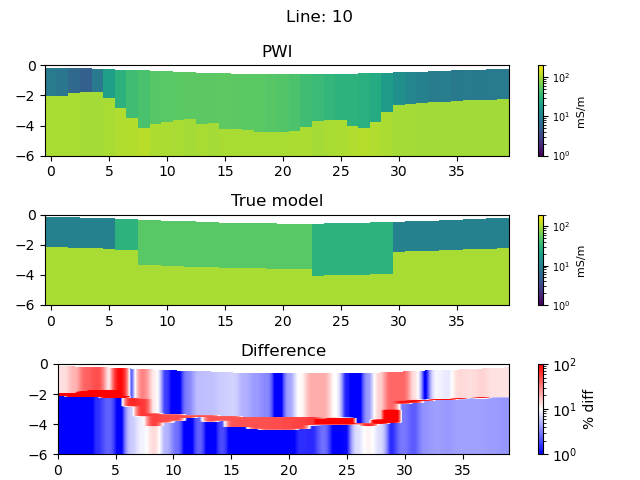

In [40]:
fig, ax = plt.subplots(3, )

l =10

showStitchedModels(m_inv[l,:,:], zMax= 6, cMin=1, cMax=200, ax=ax[0], label='mS/m')
ax[0].set_title('PWI')
showStitchedModels(model_true_full[:,l,:], zMax= 6, cMin=1, cMax=200, ax=ax[1], label='mS/m')
ax[1].set_title('True model')

c2 = ax[2].imshow(np.abs((model_inv_grid[l].T - model_true_grid[l].T)/model_true_grid[l].T)*100, extent=([0, 39,-6,0]), cmap='bwr', aspect=1.3, vmin=1, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[2], label='% diff')
ax[2].set_title('Difference')

fig.suptitle('Line: '+str( l))

plt.tight_layout()

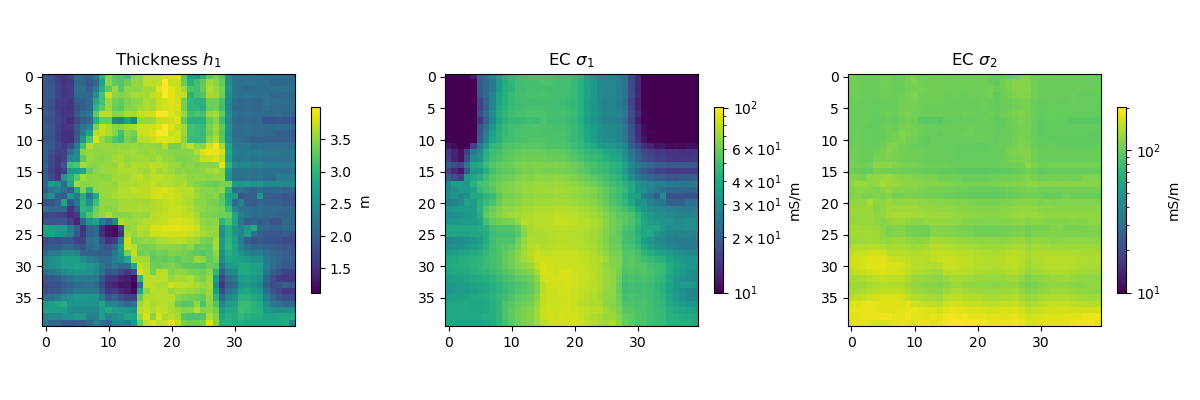

In [41]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(m[:,:,0], vmin=np.min(m[:,:,0]), vmax=np.max(m[:,:,0]))
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(m[:,:,1], vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(m[:,:,2], vmin =10, vmax=200, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

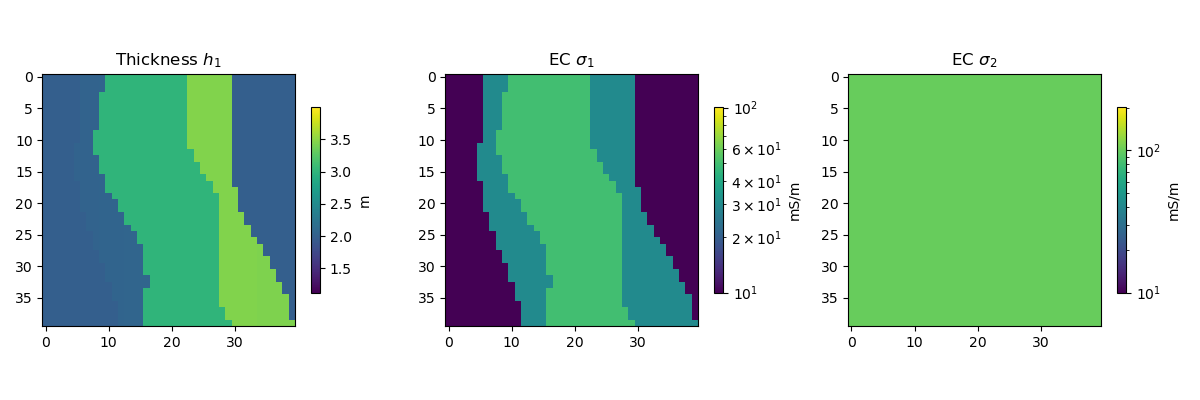

In [43]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T, vmin=np.min(m[:,:,0]), vmax=np.max(m[:,:,0]),)
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T, vmin =10, vmax=100, norm='log')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T, vmin =10, vmax=200, norm='log')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

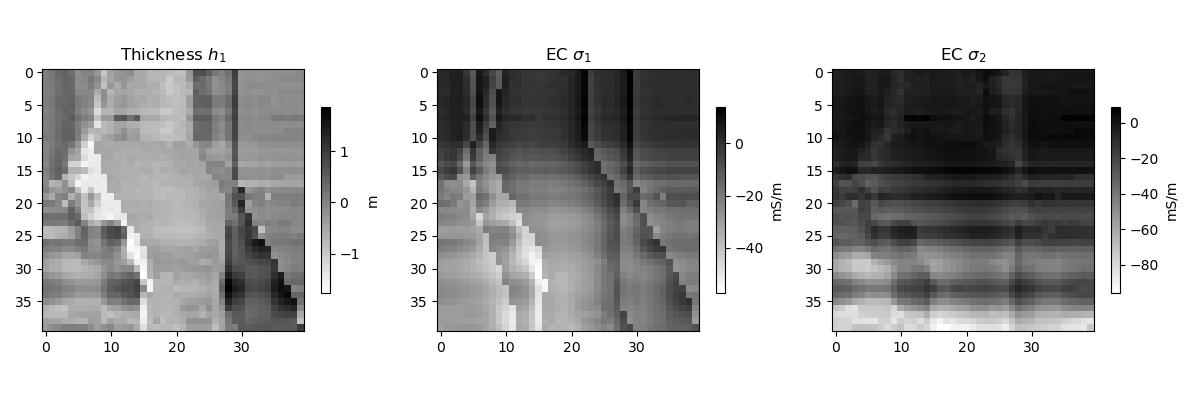

In [44]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(model_true[:,:,0].T-m[:,:,0], cmap='binary')
fig.colorbar(c1, ax=ax[0], label='m', shrink=0.5,)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(model_true[:,:,1].T-m[:,:,1], cmap='binary')
fig.colorbar(c2, ax=ax[1], label='mS/m', shrink=0.5,)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(model_true[:,:,2].T-m[:,:,2], cmap='binary')
fig.colorbar(c3, ax=ax[2], label='mS/m', shrink=0.5,)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

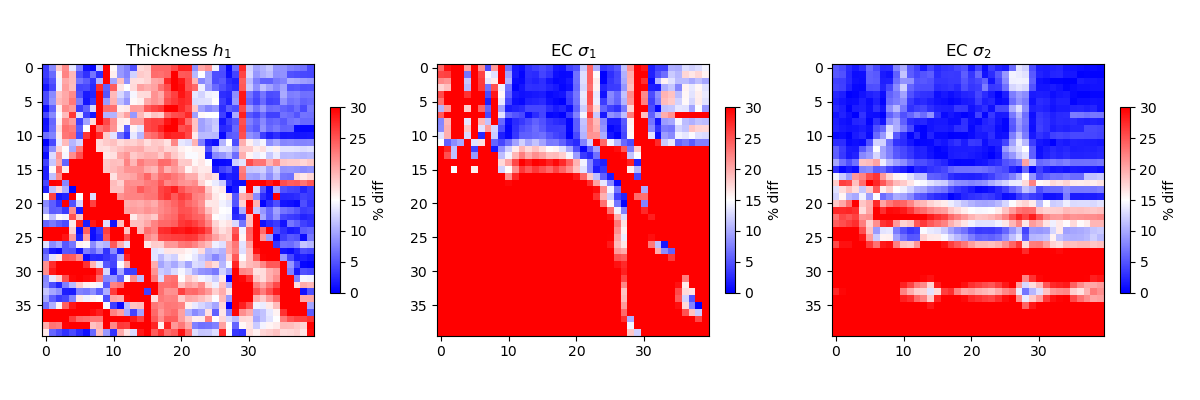

In [45]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

c1 = ax[0].imshow(np.abs((model_true[:,:,0].T-m[:,:,0])/model_true[:,:,0].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c1, ax=ax[0], label='% diff', shrink=0.5)
ax[0].set_title('Thickness $h_1$')

c2 = ax[1].imshow(np.abs((model_true[:,:,1].T-m[:,:,1])/model_true[:,:,1].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c2, ax=ax[1], label='% diff', shrink=0.5)
ax[1].set_title('EC $\sigma_1$')

c3 = ax[2].imshow(np.abs((model_true[:,:,2].T-m[:,:,2])/model_true[:,:,2].T)*100, cmap='bwr', vmin=0, vmax=30)
fig.colorbar(c3, ax=ax[2], label='% diff', shrink=0.5)
ax[2].set_title('EC $\sigma_2$')

plt.tight_layout()

# Check data fit

In [54]:
# Data in PPT

d_true = (data.copy())*1000
d_inv = (np.array(response).reshape(40,40,18))*1000

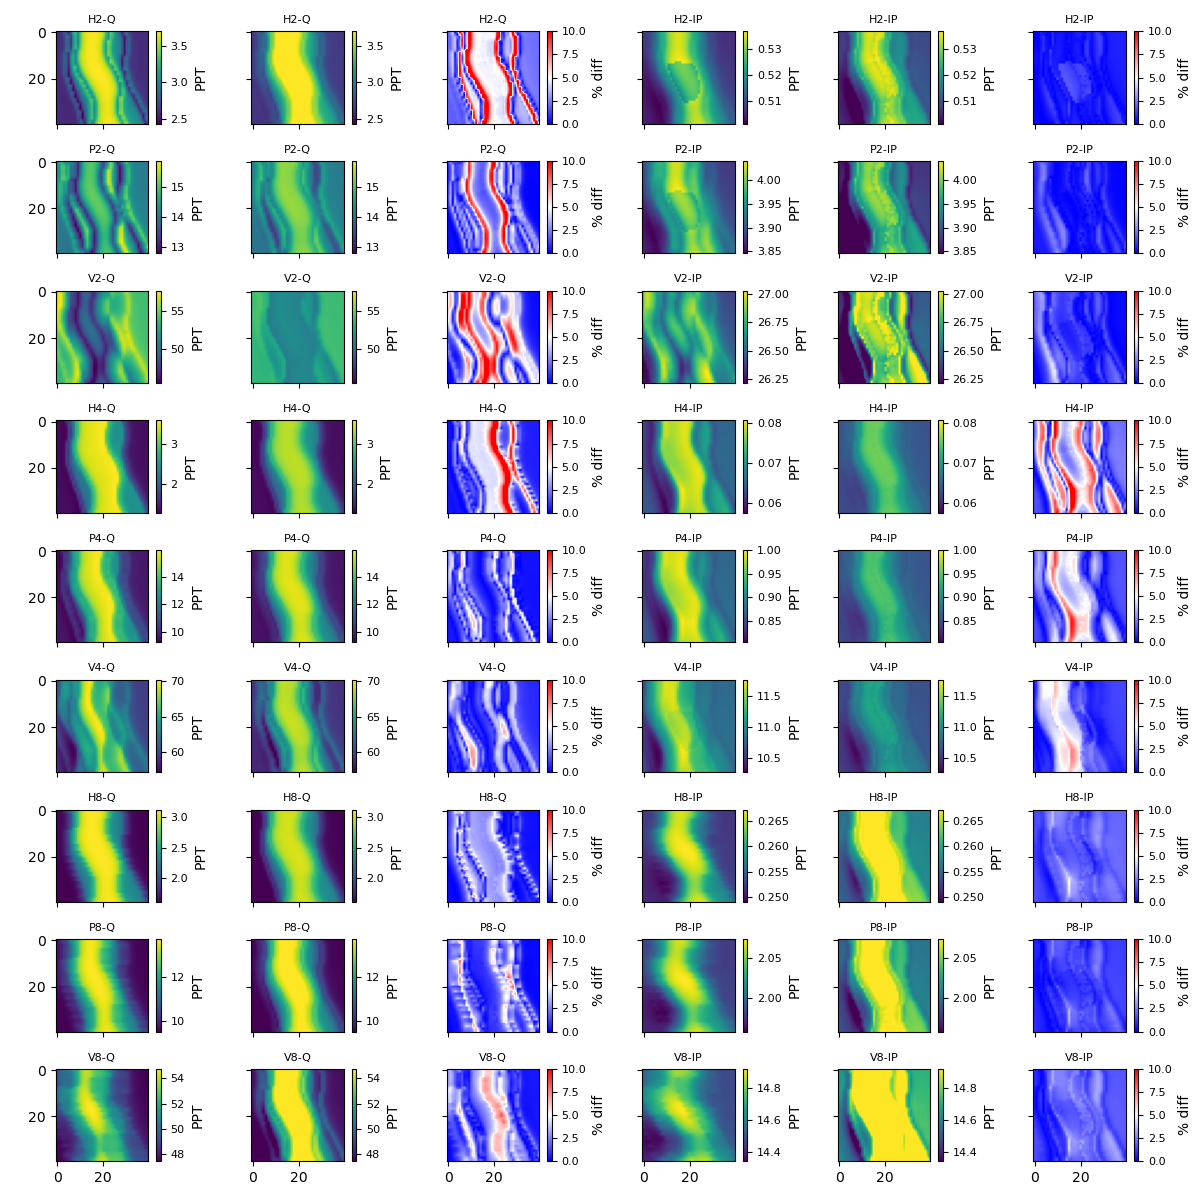

In [55]:
fig, ax = plt.subplots(9,6, figsize=(12,12), sharey=True, sharex=True)

configs = ['H2-Q', 'P2-Q', 'V2-Q', 'H4-Q', 'P4-Q', 'V4-Q', 'H8-Q', 'P8-Q', 'V8-Q', 
           'H2-IP', 'P2-IP', 'V2-IP', 'H4-IP', 'P4-IP', 'V4-IP', 'H8-IP', 'P8-IP', 'V8-IP', ]

fs=8

for i in range(9):
    vmin = min(d_true[:,i])
    vmax = max(d_true[:,i])
    
    c=ax[i,0].imshow(d_true[:,i].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,0].set_title(configs[i], fontsize=fs)
    cb = fig.colorbar(c, ax=ax[i,0], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,1].imshow(d_inv[:,:,i], vmin=vmin, vmax=vmax)
    ax[i,1].set_title(configs[i], fontsize=fs)
    cb =fig.colorbar(c, ax=ax[i,1], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,2].imshow(np.abs((d_true[:,i].reshape(40,40) - d_inv[:,:,i])/d_true[:,i].reshape(40,40))*100, cmap='bwr', vmin=0, vmax=10)
    ax[i,2].set_title(configs[i], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,2], label='% diff')
    cb.ax.tick_params(labelsize=fs)

    vmin = min(d_true[:,i+9])
    vmax = max(d_true[:,i+9])
    
    c=ax[i,3].imshow(d_true[:,i+9].reshape(40,40), vmin=vmin, vmax=vmax)
    ax[i,3].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,3], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,4].imshow(d_inv[:,:,i+9], vmin=vmin, vmax=vmax)
    ax[i,4].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,4], label='PPT')
    cb.ax.tick_params(labelsize=fs)

    c=ax[i,5].imshow(np.abs((d_true[:,i+9].reshape(40,40) - d_inv[:,:,i+9])/d_true[:,i+9].reshape(40,40))*100, cmap='bwr', vmin=0, vmax=10)
    ax[i,5].set_title(configs[i+9], fontsize=fs)
    cb=fig.colorbar(c, ax=ax[i,5], label='% diff')
    cb.ax.tick_params(labelsize=fs)


plt.tight_layout()

In [46]:
np.save('models/model_PW_Channel_topo', m_inv)

In [47]:
np.save('models/model_PW_Channel_grid_topo', model_inv_grid)